## U24AI074

### ASSIGNMENT 3

In [2]:
from visual_automata.fa.dfa import VisualDFA

dfa=VisualDFA(
    states={"q0","q1","q_err"},
    input_symbols={"[a-z]", "other"},
    transitions={
      "q0":{"[a-z]":"q1","other":"q_err"},
      "q1":{"[a-z]":"q1","other":"q_err"},
      "q_err":{"[a-z]":"q_err","other":"q_err"}
    },
    initial_state="q0",
    final_states={"q1"},
)

In [3]:
def evaluate_word(word):
    if not word: return "Not Accepted"
    current_state="q0"
    transitions=dfa.transitions
    for char in word:
        symbol="[a-z]" if char.islower() and char.isalpha() else "other"
        current_state=transitions[current_state][symbol]

    return "Accepted" if current_state in dfa.final_states else "Not Accepted"

test_strings = ["cat", "dog", "a", "zebra","dog1", "1dog", "DogHouse","Dog_house", " cats"]
for s in test_strings:
    print(f"'{s}':{evaluate_word(s)}")



'cat':Accepted
'dog':Accepted
'a':Accepted
'zebra':Accepted
'dog1':Not Accepted
'1dog':Not Accepted
'DogHouse':Not Accepted
'Dog_house':Not Accepted
' cats':Not Accepted


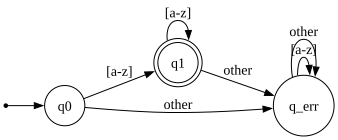

In [4]:
dfa.show_diagram()

#### Q2

## 1. FST 1: Surface to Intermediate (Orthographic Refined)

This machine resolves the surface string by explicitly preventing pluralization directly after a Consonant + Y, forcing the `i + e + s` pathway.

| **Current State** | **Surface Input** | **Intermediate Output** | **Next State** | **Functional Trigger** |
|---|---|---|---|---|
| **q0** (Start/Vowel) | `V`, `i`, `y` | (same) | **q0** | Vowel tracking. `y` after a vowel stays in q0 (allows "boys"). |
| **q0** | `C` | (same) | **qC** | Consonant tracking. |
| **q0** | `c` | `c` | **qc** | Watch for `h`. |
| **q0** | `S` (`s,x,z`) | (same) | **qsx** | Watch for e-insertion or `h` (for "sh"). |
| **q0** | $\epsilon$ | `^` | **qBnd** | Boundary insertion for regular plurals. |
| **q0** | $\epsilon$ | `#` | **qEnd** | End of singular word. |
| **qC** (Consonant) | `V` | (same) | **q0** | Reset to vowel state. |
| **qC** | `C` | (same) | **qC** | Chain consonants. |
| **qC** | `c` | `c` | **qc** | Watch for `h`. |
| **qC** | `S` (`s,x,z`) | (same) | **qsx** | Watch for e-insertion. |
| **qC** | `y` | `y` | **qCy** | Consonant + y (e.g., "try"). |
| **qC** | `i` | `y` | **qi** | Consonant + i (e.g., "tri-"). Y-replacement triggered. |
| **qc** (Read `c`) | `h` | `h` | **q_sib** | Sibilant cluster (`ch`) formed. |
| **qsx** (Read s,x,z) | `h` | `h` | **q_sib** | Sibilant cluster (`sh`) formed. |
| **qsx** | `e` | `^` | **qBnd** | E-insertion triggered directly after s, x, z. |
| **qsx** | $\epsilon$ | `#` | **qEnd** | End of singular word (e.g., "bus"). |
| **q_sib** (Read ch,sh) | `e` | `^` | **qBnd** | E-insertion triggered for ch/sh. |
| **q_sib** | $\epsilon$ | `#` | **qEnd** | End of singular word (e.g., "watch"). |
| **qCy** (Cons + y) | $\epsilon$ | `#` | **qEnd** | Valid singular ("try"). **No transition for `s` → rejects "trys".** |
| **qi** (Cons + i) | `e` | `^` | **qBnd** | Resolves Y-replacement ("tries"). |
| **qBnd** (Boundary) | `s` | `s` | **q9** | Process plural marker. |
| **q9** (Plural `s`) | $\epsilon$ | `#` | **qEnd** | Finalize plural word. |

---

## 2. FST 2: Intermediate to Lexical (Lexicon Resolution)

FST 2 requires no structural modifications from the previous iteration. It blindly accepts the sanitized outputs from FST 1 (`^s#`) and maps them to lexical tags, as orthographic anomalies have already been resolved.

| **Current State** | **Intermediate Input** | **Lexical Output** | **Next State** | **Functional Trigger** |
|---|---|---|---|---|
| **L0** | `a-z` | (same) | **L0** | Lemma construction. |
| **L0** | `#` | `+N +SG` | **L3** | Singular resolution. |
| **L0** | `^` | `+N` | **L1** | Noun tag assignment. |
| **L1** | `s` | `+PL` | **L2** | Plural tag assignment. |
| **L2** | `#` | $\epsilon$ | **L3** | |

In [13]:
import os
import pandas as pd


In [1]:
def surface_to_intermediate(word):
    word = word.strip().lower()

    if not word:
        return None

    if not word.isalpha():
        return None

    if word.endswith("ies") and len(word) > 3:
        stem = word[:-3]
        if stem and stem[-1] not in "aeiou":
            return stem + "y^s#"

    if word.endswith("shes") and len(word) > 4:
        stem = word[:-2]
        return stem + "^s#"

    if word.endswith("ches") and len(word) > 4:
        stem = word[:-2]
        return stem + "^s#"

    if word.endswith("xes") and len(word) > 3:
        stem = word[:-2]
        return stem + "^s#"

    if word.endswith("zes") and len(word) > 3:
        stem = word[:-2]
        return stem + "^s#"

    if word.endswith("ses") and len(word) > 3:
        stem = word[:-2]
        return stem + "^s#"

    if word.endswith("s") and len(word) > 1:
        stem = word[:-1]
        return stem + "^s#"

    if word.endswith("y") and len(word) > 1:
        return word + "#"

    return word + "#"

In [2]:
def intermediate_to_lexical(intermediate):
    if intermediate is None:
        return None

    if intermediate.endswith("^s#"):
        stem = intermediate[:-3]
        return stem + "+N+PL"

    if intermediate.endswith("#"):
        stem = intermediate[:-1]
        return stem + "+N+SG"

    return None

In [3]:
def surface_to_lexical(word):
    intermediate = surface_to_intermediate(word)
    lexical = intermediate_to_lexical(intermediate)
    return intermediate, lexical

In [4]:
test_words = [
    "cat",
    "cats",
    "dog",
    "dogs",
    "bus",
    "buses",
    "box",
    "boxes",
    "watch",
    "watches",
    "dish",
    "dishes",
    "try",
    "tries",
    "boy",
    "boys"
]

for word in test_words:
    intermediate, lexical = surface_to_lexical(word)
    print(f"{word:10} -> {intermediate:15} -> {lexical}")

cat        -> cat#            -> cat+N+SG
cats       -> cat^s#          -> cat+N+PL
dog        -> dog#            -> dog+N+SG
dogs       -> dog^s#          -> dog+N+PL
bus        -> bu^s#           -> bu+N+PL
buses      -> bus^s#          -> bus+N+PL
box        -> box#            -> box+N+SG
boxes      -> box^s#          -> box+N+PL
watch      -> watch#          -> watch+N+SG
watches    -> watch^s#        -> watch+N+PL
dish       -> dish#           -> dish+N+SG
dishes     -> dish^s#         -> dish+N+PL
try        -> try#            -> try+N+SG
tries      -> try^s#          -> try+N+PL
boy        -> boy#            -> boy+N+SG
boys       -> boy^s#          -> boy+N+PL


In [7]:
brown_file = "brown_nouns.txt"

if not os.path.exists(brown_file):
    raise FileNotFoundError("brown_nouns.txt was not found in the current folder.")

print("File found:", brown_file)

File found: brown_nouns.txt


In [8]:
with open(brown_file, "r", encoding="utf-8") as f:
    brown_nouns = [line.strip() for line in f if line.strip()]

print("Total entries:", len(brown_nouns))
print(brown_nouns[:20])

Total entries: 202793
['investigation', 'primary', 'election', 'evidence', 'irregularities', 'place', 'jury', 'presentments', 'charge', 'election', 'praise', 'thanks', 'manner', 'election', 'term', 'jury', 'reports', 'irregularities', 'primary', 'handful']


In [16]:
results = []

for word in brown_nouns:
    intermediate, lexical = surface_to_lexical(word)

    if lexical is not None:
        results.append(
            {
                "Surface": word,
                "Intermediate": intermediate,
                "Lexical": lexical
            }
        )

In [17]:
results_df = pd.DataFrame(results)

print("Successfully converted:", len(results_df))
results_df.head(20)

Successfully converted: 201654


,Surface,Intermediate,Lexical
0,investigation,investigation#,investigation+N+SG
1,primary,primary#,primary+N+SG
2,election,election#,election+N+SG
3,evidence,evidence#,evidence+N+SG
4,irregularities,irregularity^s#,irregularity+N+PL
5,place,place#,place+N+SG
6,jury,jury#,jury+N+SG
7,presentments,presentment^s#,presentment+N+PL
8,charge,charge#,charge+N+SG
9,election,election#,election+N+SG


In [18]:
output_file = "brown_nouns_lexical.txt"

with open(output_file, "w", encoding="utf-8") as f:
    for _, row in results_df.iterrows():
        f.write(
            f"{row['Surface']}\t{row['Intermediate']}\t{row['Lexical']}\n"
        )

print("Output file created:", output_file)

Output file created: brown_nouns_lexical.txt


In [19]:
with open(output_file, "r", encoding="utf-8") as f:
    for line in list(f)[:20]:
        print(line.strip())

investigation	investigation#	investigation+N+SG
primary	primary#	primary+N+SG
election	election#	election+N+SG
evidence	evidence#	evidence+N+SG
irregularities	irregularity^s#	irregularity+N+PL
place	place#	place+N+SG
jury	jury#	jury+N+SG
presentments	presentment^s#	presentment+N+PL
charge	charge#	charge+N+SG
election	election#	election+N+SG
praise	praise#	praise+N+SG
thanks	thank^s#	thank+N+PL
manner	manner#	manner+N+SG
election	election#	election+N+SG
term	term#	term+N+SG
jury	jury#	jury+N+SG
reports	report^s#	report+N+PL
irregularities	irregularity^s#	irregularity+N+PL
primary	primary#	primary+N+SG
handful	handful#	handful+N+SG


In [20]:
print("Surface to Lexical conversion completed.")
print(f"Input file: {brown_file}")
print(f"Output file: {output_file}")
print(f"Total input entries: {len(brown_nouns)}")
print(f"Total converted entries: {len(results_df)}")

Surface to Lexical conversion completed.
Input file: brown_nouns.txt
Output file: brown_nouns_lexical.txt
Total input entries: 202793
Total converted entries: 201654
